In [ ]:
# Instalar dependencias
!pip install git+https://github.com/huggingface/transformers.git
!pip install accelerate timm





Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/huggingface/transformers.git to C:\Users\Sergio\AppData\Local\Temp\pip-req-build-87aqajkj
  Resolved https://github.com/huggingface/transformers.git to commit f324707307757d9c0b8dac1c4462eceff911fa2f
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git 'C:\Users\Sergio\AppData\Local\Temp\pip-req-build-87aqajkj'

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Sergio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Sergio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
# ============================================================
# 2. IMPORTAR LIBRERÍAS
# ============================================================

from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image, ImageDraw, ImageFont
import torch
import json
import matplotlib.pyplot as plt
import textwrap
import os
import re
import time

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

PyTorch: 2.14.0+cpu
CUDA disponible: False


In [10]:
# ============================================================
# 3. CARGAR MODELO Y PROCESADOR
# ============================================================

model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"

processor = DonutProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name)

# Usar GPU si está disponible; de lo contrario, CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Modelo cargado:", model_name)
print("Dispositivo:", device)

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

Modelo cargado: naver-clova-ix/donut-base-finetuned-cord-v2
Dispositivo: cpu


Usando imagen: image.png


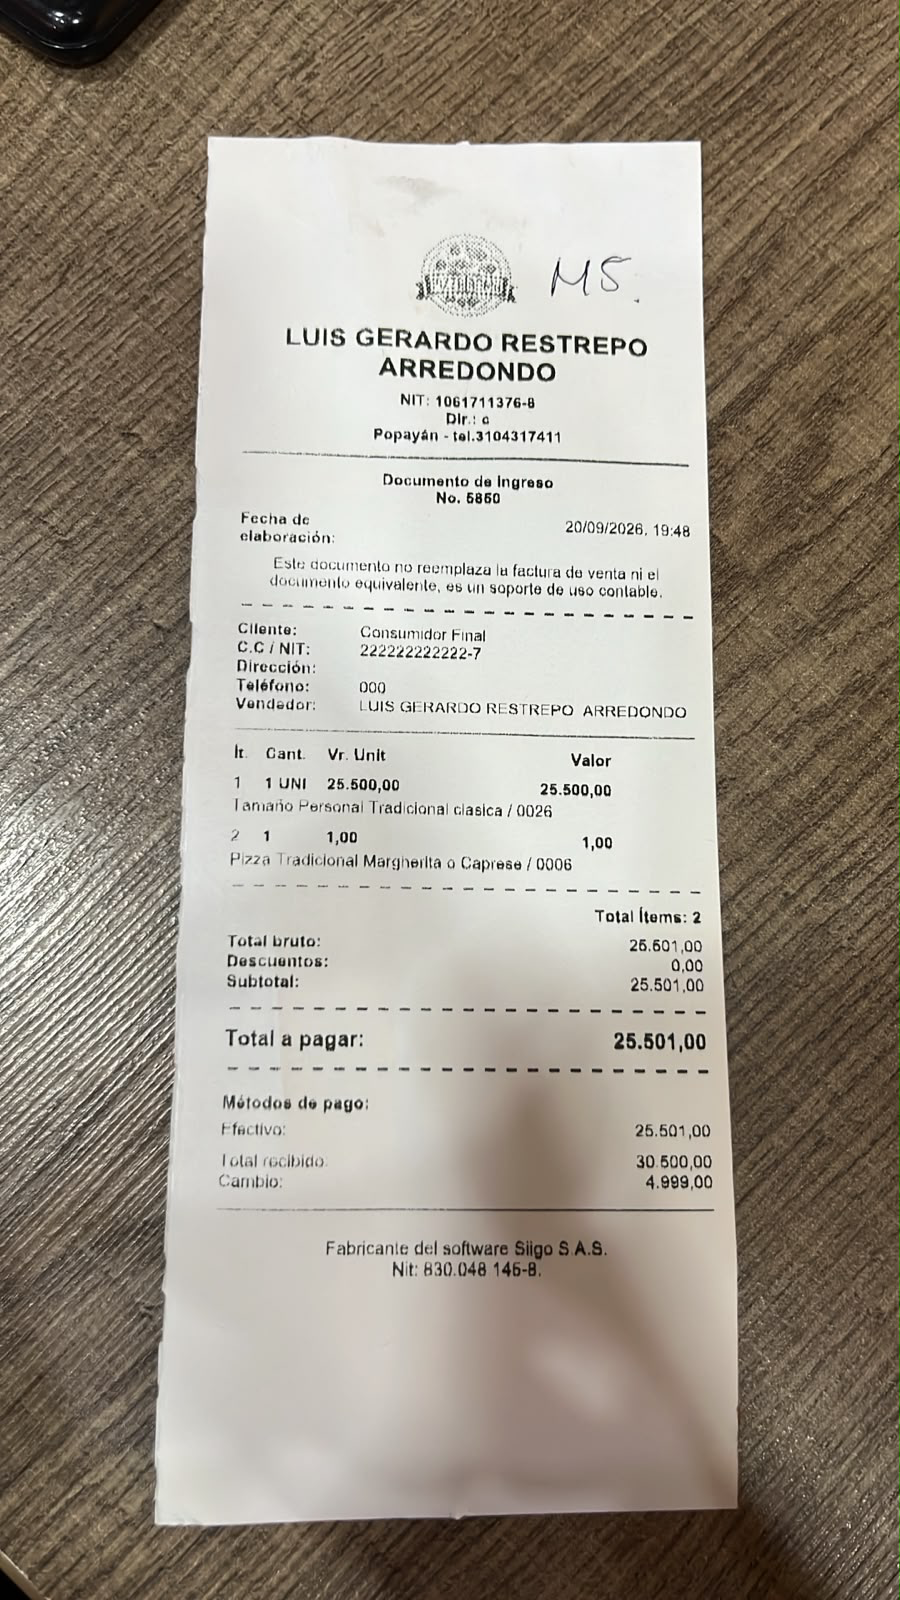

In [11]:
# ============================================================
# 4. CARGAR LA IMAGEN
# ============================================================
# Cambia esta ruta si deseas analizar otra imagen.
# En tu repositorio actual puedes dejar "image.png".

image_path = "image.png"

if os.path.exists(image_path):
    image = Image.open(image_path).convert("RGB")
    print("Usando imagen:", image_path)
else:
    print(f"No se encontró '{image_path}'. Se generará un recibo sintético de prueba.")

    image = Image.new("RGB", (480, 560), color="white")
    draw = ImageDraw.Draw(image)

    def get_font(size):
        try:
            return ImageFont.truetype("DejaVuSans.ttf", size)
        except OSError:
            return ImageFont.load_default()

    draw.text((20, 20), "CAFE CENTRAL", fill="black", font=get_font(26))
    draw.text((20, 60), "Fecha: 2024-05-14", fill="black", font=get_font(16))

    y = 110
    for name, price in [
        ("Cafe Americano", "3.50"),
        ("Croissant", "2.75"),
        ("Jugo Naranja", "4.20"),
    ]:
        draw.text((20, y), name, fill="black", font=get_font(18))
        draw.text((360, y), price, fill="black", font=get_font(18))
        y += 34

    draw.text((20, y + 24), "TOTAL", fill="black", font=get_font(20))
    draw.text((360, y + 24), "10.45", fill="black", font=get_font(20))

display(image)


In [12]:
# ============================================================
# 5. PREPROCESAR LA IMAGEN
# ============================================================
# DonutProcessor convierte la imagen al tensor pixel_values
# que recibe el encoder visual (Swin Transformer).

pixel_values = processor(
    image,
    return_tensors="pt"
).pixel_values

pixel_values = pixel_values.to(device)

print("Forma de pixel_values:", tuple(pixel_values.shape))
print("Tipo:", pixel_values.dtype)
print("Dispositivo:", pixel_values.device)


Forma de pixel_values: (1, 3, 1280, 960)
Tipo: torch.float32
Dispositivo: cpu


In [13]:
# ============================================================
# 6. PREPARAR EL PROMPT DEL DECODER
# ============================================================
# <s_cord-v2> indica al decoder que debe realizar la tarea
# asociada al modelo fine-tuned sobre CORD v2.

task_prompt = "<s_cord-v2>"

decoder_input_ids = processor.tokenizer(
    task_prompt,
    add_special_tokens=False,
    return_tensors="pt"
).input_ids.to(device)

print("Prompt:", task_prompt)
print("decoder_input_ids:", decoder_input_ids)

Prompt: <s_cord-v2>
decoder_input_ids: tensor([[57579]])


In [14]:
# ============================================================
# 7. INFERENCIA ESTABILIZADA
# ============================================================
# Se mantienen parámetros conservadores para no alterar demasiado
# la generación estructurada de Donut.
#
# repetition_penalty ayuda a reducir bucles de repetición.
# no_repeat_ngram_size evita repeticiones largas exactas.
# max_length limita la longitud total de la salida.

start_time = time.perf_counter()

with torch.inference_mode():
    outputs = model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=512,
        do_sample=False,
        num_beams=1,
        repetition_penalty=1.15,
        no_repeat_ngram_size=4,
        use_cache=True,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
    )

inference_time = time.perf_counter() - start_time

print(f"Tiempo de inferencia: {inference_time:.2f} segundos")
print("Tokens generados:", outputs.shape[-1])

Tiempo de inferencia: 14.62 segundos
Tokens generados: 241


In [15]:
# ============================================================
# 8. DECODIFICAR Y LIMPIAR LA SECUENCIA
# ============================================================
# NO usamos skip_special_tokens=True aquí porque Donut utiliza
# etiquetas especiales como <s_menu>, <s_nm>, etc. para construir
# posteriormente la estructura JSON.

raw_sequence = processor.batch_decode(outputs)[0]

sequence = raw_sequence.replace(
    processor.tokenizer.eos_token or "",
    ""
).replace(
    processor.tokenizer.pad_token or "",
    ""
)

# Eliminar solamente el primer token de tarea, por ejemplo <s_cord-v2>.
# Las demás etiquetas estructurales se conservan.
sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()

print("========== SALIDA RAW ==========")
print(raw_sequence)

print("\n========== SECUENCIA LIMPIA ==========")
print(sequence)


========== SALIDA RAW ==========
<s_cord-v2><s_menu><s_nm> LUIS GERARD NONDON</s_nm><s_price> RSTREPO</s_price><sep/><s_nm> ANREDONDO</s_nm><sep/><s_nm> NT: 1067113786-8</s_price><sep/><s_nm> Popayn -T. 15104317411</s_nm><s_unitprice> @0.636</s_unitprice><s_cnt> 11</s_cnt><s_price> MS Documento Ide Ingroo</s_nm><s_unitprice> @00</s_unitprice><s_cnt> 0.6</s_unitprice><s_cnt> 0.0</s_cnt><s_price> 2009/2026,1948</s_price><sep/><s_nm> Esle cooument no ro到底 ia factura de vente nimel</s_nm><s_unitprice> @omamento souvenire. se um sporto</s_nm><s_price> do use contabic.</s_price><sep/><s_nm> Cliente:</s_nm><s_unitprice> 222222222乌rijke C.C. INIT:</s_nm><s_unitprice> 22421</s_unitprice><s_cnt> 3</s_cnt><s_price> Direculon</s_nm><s_unitprice> TOblofonio: 000</s_unitprice><s_cnt> 800</s_cnt><s_price> ARED ONDO Nederlandse LUS GERADRO RESTREPO</s_nm><s_price> Velor</s_price><sep/><s_nm> Itt. Cart. Vulnt</s_nm><s_unitprice> 25.500.00</s_unitprice><s_cnt> 1</s_cnt><s_price> 25,500,00</s_price><sep/

In [16]:
# ============================================================
# 9. CONVERTIR A RESULTADO ESTRUCTURADO
# ============================================================
# token2json interpreta las etiquetas generadas por Donut y
# las convierte a un diccionario de Python.

try:
    result = processor.token2json(sequence)

    print("========== RESULTADO ESTRUCTURADO ==========")
    print(json.dumps(result, indent=4, ensure_ascii=False))

except Exception as e:
    print("No fue posible convertir automáticamente la salida a JSON.")
    print("Detalle del error:", e)

    # Conservamos la secuencia para no perder el resultado generado.
    result = {
        "raw_output": sequence,
        "conversion_error": str(e)
    }

========== RESULTADO ESTRUCTURADO ==========
[
    {
        "nm": "LUIS GERARD NONDON",
        "price": "RSTREPO"
    },
    {
        "nm": "ANREDONDO"
    },
    {
        "unitprice": "@0.636",
        "cnt": "11",
        "price": {
            "unitprice": "@00"
        }
    },
    {
        "nm": "Esle cooument no ro到底 ia factura de vente nimel",
        "unitprice": [
            {
                "price": "do use contabic."
            },
            {
                "nm": "Cliente:"
            }
        ],
        "cnt": "3",
        "price": {
            "unitprice": "TOblofonio: 000",
            "cnt": "800"
        }
    },
    {
        "nm": "Itt. Cart. Vulnt",
        "unitprice": "25.500.00",
        "cnt": "1",
        "price": "25,500,00"
    },
    {
        "nm": "UNI",
        "unitprice": "為mono Personal Traditional classica/0026",
        "menuqty_cnt": [
            "1.00</s_price>",
            ""
        ]
    }
]


C:\Users\Sergio\AppData\Local\Temp\ipykernel_13432\1682195757.py:51: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Sergio\AppData\Local\Temp\ipykernel_13432\1682195757.py:51: UserWarning: Glyph 24213 (\N{CJK UNIFIED IDEOGRAPH-5E95}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Sergio\AppData\Local\Temp\ipykernel_13432\1682195757.py:51: UserWarning: Glyph 28858 (\N{CJK UNIFIED IDEOGRAPH-70BA}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Sergio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\si

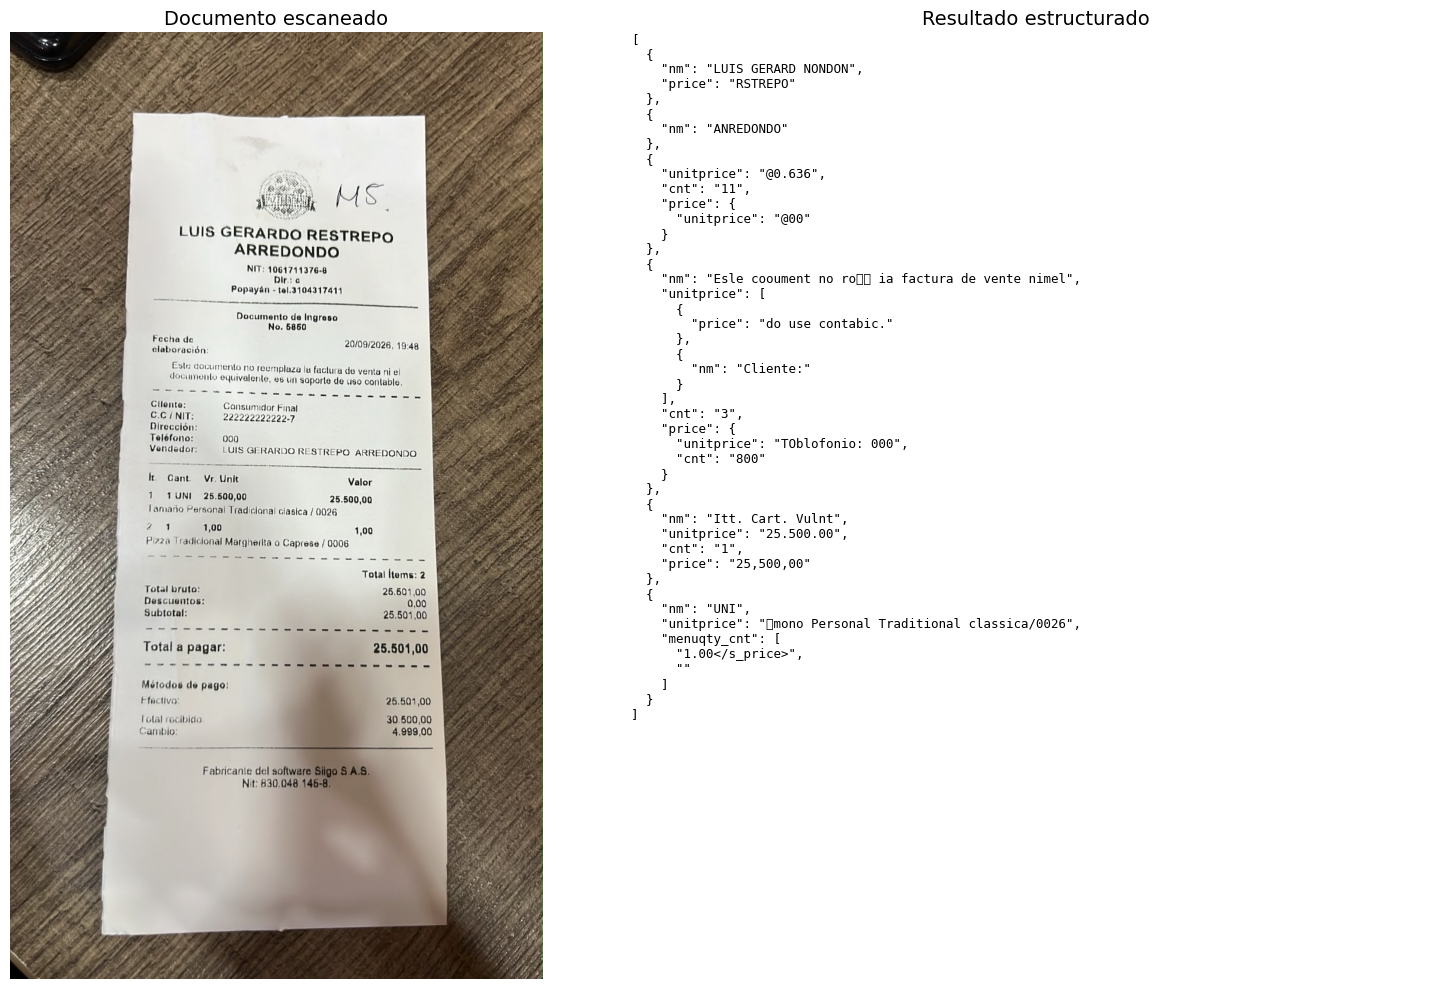

Tiempo de inferencia: 14.62 s


In [17]:
# ============================================================
# 10. VISUALIZAR DOCUMENTO + RESULTADO
# ============================================================

if isinstance(result, (dict, list)):
    display_result = json.dumps(
        result,
        indent=2,
        ensure_ascii=False
    )
else:
    display_result = str(result)

fig, ax = plt.subplots(1, 2, figsize=(16, 10))

# Documento original
ax[0].imshow(image)
ax[0].axis("off")
ax[0].set_title("Documento escaneado", fontsize=14)

# Resultado estructurado
ax[1].axis("off")
ax[1].set_title("Resultado estructurado", fontsize=14)

# Ajustar líneas largas sin destruir el formato por completo.
wrapped_lines = []
for line in display_result.splitlines():
    if len(line) > 80:
        wrapped_lines.extend(
            textwrap.wrap(
                line,
                width=80,
                subsequent_indent="    "
            )
        )
    else:
        wrapped_lines.append(line)

display_result_wrapped = "\n".join(wrapped_lines)

ax[1].text(
    0,
    1,
    display_result_wrapped,
    fontsize=9,
    va="top",
    ha="left",
    family="monospace"
)

plt.tight_layout()
plt.show()

print(f"Tiempo de inferencia: {inference_time:.2f} s")
